# Batch Gredeant Decent Method 


## import required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  




In [2]:
df = pd.read_csv("after_houseprice_dataset.csv")
print(df.head())

   area_sqft  bedrooms  bathrooms  location_score  house_price_inr
0       1973         5          4             7.6         40275084
1       1560         3          3             6.3         26812029
2       2071         4          3             5.8         29315677
3       2640         5          3             7.7         47712959
4       1498         3          3             3.8         17724566


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_sqft        4200 non-null   int64  
 1   bedrooms         4200 non-null   int64  
 2   bathrooms        4200 non-null   int64  
 3   location_score   4200 non-null   float64
 4   house_price_inr  4200 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 164.2 KB


In [4]:
df.describe()

,area_sqft,bedrooms,bathrooms,location_score,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,7.611172e+07


In [5]:
df.shape

(4200, 5)

In [6]:

def run_gd(grad_fn, w0, lr=0.05, steps=80):
    w = np.array(w0, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        w -= lr * grad_fn(w)
        path.append(w.copy())
    return np.array(path)

# Convex: simple quadratic bowl
def grad_convex(w):
    # f(w1,w2) = 0.5*(w1^2 + 2*w2^2)
    return np.array([w[0], 2*w[1]])

convex_path = run_gd(grad_convex, w0=[2.5, -2.0], lr=0.15, steps=30)
print("Convex final point:", convex_path[-1])

# Non‑convex: Rosenbrock valley
def grad_rosenbrock(w):
    # f(w1,w2) = (1 - w1)^2 + 100*(w2 - w1**2)**2
    x, y = w
    dfdx = -2*(1 - x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])

rosen_path = run_gd(grad_rosenbrock, w0=[-1.5, 1.5], lr=0.0015, steps=4000)
print("Non‑convex final point (Rosenbrock):", rosen_path[-1])


Convex final point: [ 1.90768990e-02 -4.50786806e-05]
Non‑convex final point (Rosenbrock): [0.95681441 0.91531647]


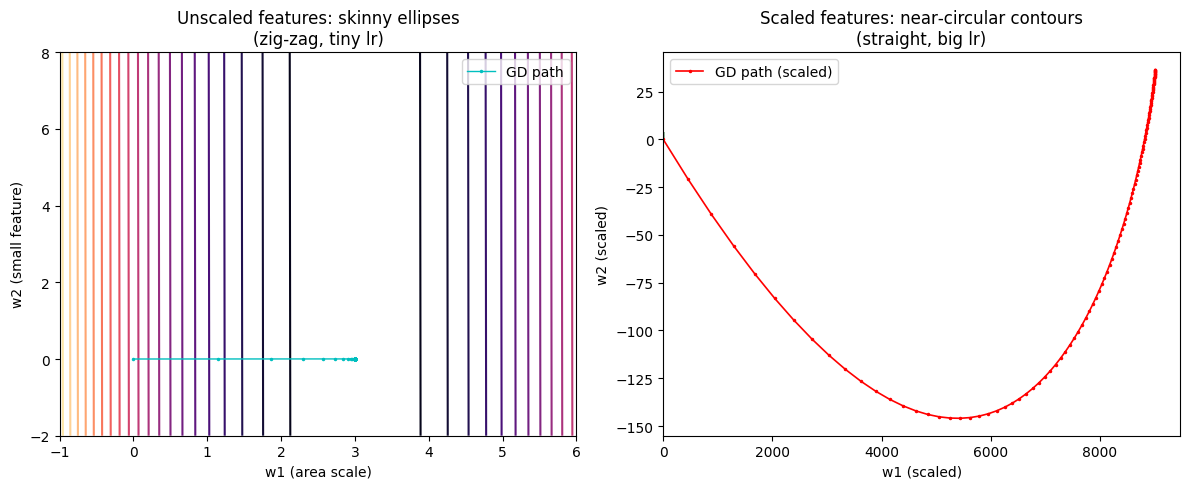

In [7]:


# Synthetic 2‑feature regression with very different scales
rng = np.random.default_rng(0)
n = 200
x1 = rng.uniform(0, 10000, n)   # big scale
x2 = rng.uniform(0, 10, n)      # small scale
X = np.c_[x1, x2]
true_w = np.array([3.0, 4.0])
y = X @ true_w + rng.normal(0, 500, n)

def run_gd(X, y, lr, steps):
    w = np.zeros(X.shape[1])
    path = [w.copy()]
    for _ in range(steps):
        grad = (X.T @ (X @ w - y)) / len(y)
        w -= lr * grad
        path.append(w.copy())
    return np.array(path)

# Unscaled run
path_raw = run_gd(X, y, lr=1e-8, steps=1200)

# Scaled run
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
path_scaled = run_gd(Xs, y, lr=0.05, steps=120)

# Contour helper
def loss_grid(X, y, w1_range, w2_range):
    W1, W2 = np.meshgrid(w1_range, w2_range)
    Z = np.zeros_like(W1)
    for i in range(W1.shape[0]):
        w = np.stack([W1[i], W2[i]], axis=1)
        pred = X @ w.T
        Z[i] = ((pred - y[:,None])**2).mean(axis=0) / 2
    return W1, W2, Z

w1r = np.linspace(-1, 6, 120)
w2r = np.linspace(-2, 8, 120)
W1, W2, Z_raw = loss_grid(X, y, w1r, w2r)

# For scaled contour, ranges in scaled weight space
w1rs = np.linspace(-0.5, 4, 120)
w2rs = np.linspace(-0.5, 4, 120)
W1s, W2s, Z_scaled = loss_grid(Xs, y, w1rs, w2rs)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].contour(W1, W2, Z_raw, levels=25, cmap="magma")
axs[0].plot(path_raw[:,0], path_raw[:,1], "c.-", ms=3, lw=1, label="GD path")
axs[0].set_title("Unscaled features: skinny ellipses\n(zig‑zag, tiny lr)")
axs[0].set_xlabel("w1 (area scale)"); axs[0].set_ylabel("w2 (small feature)")
axs[0].legend()

axs[1].contour(W1s, W2s, Z_scaled, levels=25, cmap="viridis")
axs[1].plot(path_scaled[:,0], path_scaled[:,1], "r.-", ms=3, lw=1.2, label="GD path (scaled)")
axs[1].set_title("Scaled features: near‑circular contours\n(straight, big lr)")
axs[1].set_xlabel("w1 (scaled)"); axs[1].set_ylabel("w2 (scaled)")
axs[1].legend()

plt.tight_layout()
plt.show()


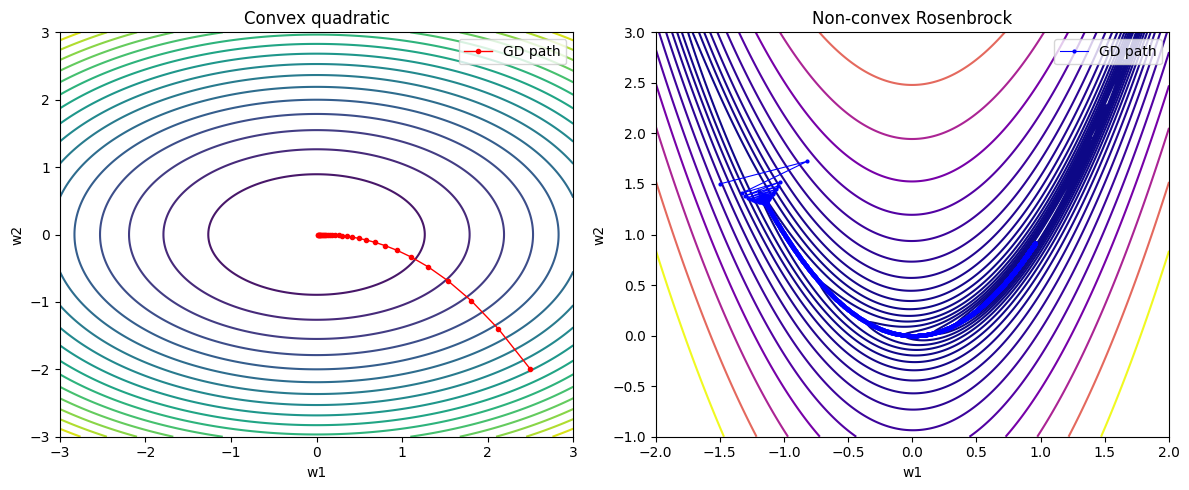

In [8]:
# Plot trajectories
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Convex contours
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Zc = 0.5*(X**2 + 2*Y**2)
axs[0].contour(X, Y, Zc, levels=20, cmap="viridis")
axs[0].plot(convex_path[:,0], convex_path[:,1], "ro-", ms=3, lw=1, label="GD path")
axs[0].set_title("Convex quadratic")
axs[0].legend()

# Rosenbrock contours (non‑convex)
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Zr = (1 - X)**2 + 100*(Y - X**2)**2
axs[1].contour(X, Y, Zr, levels=np.logspace(-1, 3, 20), cmap="plasma")
axs[1].plot(rosen_path[:,0], rosen_path[:,1], "bo-", ms=2, lw=0.8, label="GD path")
axs[1].set_title("Non‑convex Rosenbrock")
axs[1].legend()

for ax in axs:
    ax.set_xlabel("w1"); ax.set_ylabel("w2")
plt.tight_layout()
plt.show()



In [9]:

X = df[["area_sqft","bedrooms","bathrooms","location_score"]].values
y = df[["house_price_inr"]].values  # column vector

# 3) Scale features for stable gradients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) Add bias column (intercept)
Xb = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])  # shape (n, d+1)

# 5) Hyperparameters
lr = 0.01          # learning rate
epochs = 2000
theta = np.zeros((Xb.shape[1], 1))  # (d+1, 1)

def loss(Xb, y, theta):
    err = Xb @ theta - y
    return (err**2).mean() / 2  # MSE/2

# 6) Batch Gradient Descent
for epoch in range(epochs):
    err = Xb @ theta - y
    grad = (Xb.T @ err) / len(y)   # full-batch gradient
    theta -= lr * grad
    if epoch % 200 == 0:
        print(f"{epoch:4d}  loss={loss(Xb, y, theta):.2e}")

print("Final loss:", loss(Xb, y, theta))

# 7) Prediction helper (expects raw feature values in original scale)
def predict(rows):
    rows = np.asarray(rows)
    rows_scaled = scaler.transform(rows)
    rows_b = np.hstack([np.ones((rows_scaled.shape[0],1)), rows_scaled])
    return (rows_b @ theta).ravel()

# Example prediction
example = [[2000, 4, 3, 7.0]]
print("Predicted price:", predict(example)[0])


   0  loss=3.48e+14
 200  loss=1.40e+13
 400  loss=7.41e+12
 600  loss=6.87e+12
 800  loss=6.69e+12
1000  loss=6.60e+12
1200  loss=6.55e+12
1400  loss=6.53e+12
1600  loss=6.51e+12
1800  loss=6.50e+12
Final loss: 6495788879592.527
Predicted price: 33113443.55744888


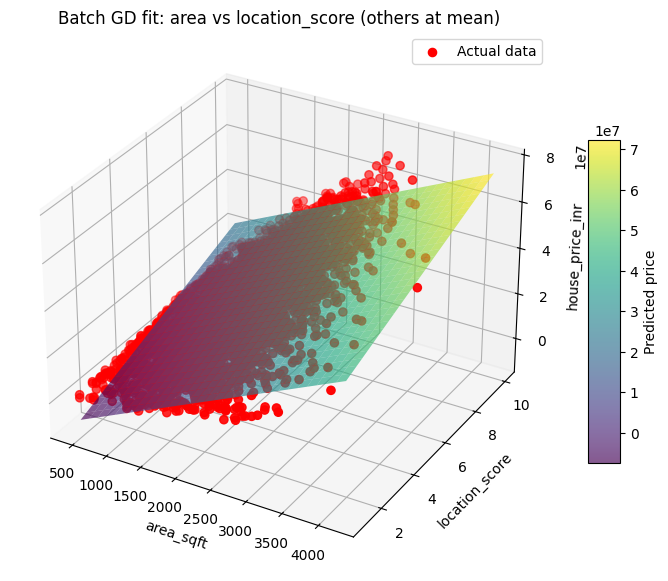

In [10]:

# Choose two axes to visualize; keep other features at their mean
mean_bed = df.bedrooms.mean()
mean_bath = df.bathrooms.mean()

area_min, area_max = df.area_sqft.min(), df.area_sqft.max()
loc_min, loc_max = df.location_score.min(), df.location_score.max()

area_grid = np.linspace(area_min, area_max, 30)
loc_grid  = np.linspace(loc_min, loc_max, 30)
A, L = np.meshgrid(area_grid, loc_grid)

# Build grid rows with other features fixed to their means
grid_rows = np.c_[A.ravel(),
                  np.full(A.size, mean_bed),
                  np.full(A.size, mean_bath),
                  L.ravel()]

Z = predict(grid_rows).reshape(A.shape)  # predicted price surface

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Surface of model predictions
surf = ax.plot_surface(A, L, Z, cmap="viridis", alpha=0.65, linewidth=0, antialiased=True)

# Scatter of actual data
ax.scatter(df.area_sqft, df.location_score, df.house_price_inr,
           color="red", s=35, label="Actual data", depthshade=True)

ax.set_xlabel("area_sqft")
ax.set_ylabel("location_score")
ax.set_zlabel("house_price_inr")
ax.set_title("Batch GD fit: area vs location_score (others at mean)")
ax.legend()
fig.colorbar(surf, shrink=0.6, aspect=10, label="Predicted price")
plt.show()
